# HI 5304 — Intro to R in Jupyter (Cardio10)

In this notebook you will:
- Import a CSV dataset (`cardio10.csv`)
- Inspect and summarize data
- Create a few clinically meaningful summaries
- Make a simple plot
- Answer short interpretation questions

**Dataset:** cardio10.csv  
**Kernel:** R (4.2.2)


In [1]:
version$version.string
Sys.which("R")
getwd()


[1] "R version 4.2.2 Patched (2022-11-10 r83330)"

R 
"/usr/bin/R"

[1] "/workspaces/hi5304-notebooks/learning"

In [ ]:
pkgs <- c("tidyverse", "janitor", "skimr")

installed <- rownames(installed.packages())
to_install <- setdiff(pkgs, installed)

if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

library(tidyverse)
library(janitor)
library(skimr)


In [ ]:
install.packages("janitor", repos = "https://cloud.r-project.org")


In [ ]:
dir.create(Sys.getenv("R_LIBS_USER"), recursive = TRUE, showWarnings = FALSE)
.libPaths(Sys.getenv("R_LIBS_USER"))
.libPaths()


In [ ]:
install.packages(c("tidyverse","janitor","skimr"), repos = "https://cloud.r-project.org")


In [ ]:
pkgs <- c("tidyverse", "janitor", "skimr")

dir.create(Sys.getenv("R_LIBS_USER"), recursive = TRUE, showWarnings = FALSE)
.libPaths(Sys.getenv("R_LIBS_USER"))

for (p in pkgs) {
  if (!requireNamespace(p, quietly = TRUE)) {
    message("Installing: ", p)
    try(install.packages(p, repos = "https://cloud.r-project.org"), silent = TRUE)
  }
}

# Load what’s available
invisible(lapply(pkgs, function(p) {
  if (requireNamespace(p, quietly = TRUE)) library(p, character.only = TRUE)
}))


In [4]:
library(tidyverse)
library(janitor)
library(skimr)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




Creating and connecting data frames
Creating a data frame in RStudio is a fundamental task for data manipulation and analysis. Here are the steps to create a data frame in RStudio:
Step-by-Step Guide
1.	Open RStudio: Start RStudio on your computer.
2.	Create a New Script: Open a new R script by clicking on File > New File > R Script.
3.	Define Your Data: Use vectors to define your data.
4.	Create the Data Frame: Use the data.frame() function to create a data frame from the vectors.
5.	Assign the Data Frame to a Variable: Store the data frame in a variable.
Example
Suppose you want to create a data frame with information about individuals' height and weight.
Step 1: Define Your Data


In [1]:
# Define vectors
height_cm <- c(170, 165, 180, 175)
weight_kg <- c(70, 60, 80, 75)

# Create data frame
df <- data.frame(
  height_cm = height_cm,
  weight_kg = weight_kg
)

# Display the data frame
print(df)




  height_cm weight_kg
1       170        70
2       165        60
3       180        80
4       175        75


One-Sample t Test
Purpose:
•	To determine whether the mean of a single sample is significantly different from a known or hypothesized population mean.
•	Commonly used when comparing a sample average (e.g., a clinical measurement) against a standard or established value.
Variable Requirements:
•	Dependent Variable: One continuous variable (measured on an interval or ratio scale).
•	Reference Value: A known or hypothesized mean value for comparison.
Assumptions:
•	Independence: Observations in the sample must be independent of one another.
•	Normality: The data (or differences from the hypothesized mean) should be approximately normally distributed. For larger sample sizes (typically n > 30), the t test is robust to deviations from normality.
•	Scale of Measurement: The dependent variable should be measured at least at an interval level.

Example in Public Health:
Consider a public health researcher who wants to assess whether the average blood pressure of a sample of individuals from a community is significantly different from a national average blood pressure level (which is known from previous studies).
•	Population Mean: National average blood pressure level (e.g., systolic blood pressure = 120 mmHg).
•	Sample: A random sample of 50 individuals from the community.
•	Hypothesis: The researcher hypothesizes that the average blood pressure in the community is different from the national average.
Steps for conducting a one-sample t-test:
1.	Collect Data: Measure the blood pressure of each individual in the sample.
2.	Define Hypotheses:
1.	Null Hypothesis (H₀): The average blood pressure in the community is equal to the national average (μ = 120 mmHg).
2.	Alternative Hypothesis (H₁): The average blood pressure in the community is different from the national average (μ ≠ 120 mmHg).
3.	Calculate the t-statistic: Compute the t-statistic using the formula: t=xˉ−μsnt = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}}t=nsxˉ−μ where xˉ\bar{x}xˉ is the sample mean, μ\muμ is the population mean (120 mmHg), sss is the sample standard deviation, and nnn is the sample size.
4.	Compare with Critical Value: Compare the calculated t-statistic with the critical t-value from the t-distribution table (based on degrees of freedom and chosen significance level, typically α = 0.05).


In [2]:
# Sample data
data <- c(5.1, 4.8, 5.3, 5.7, 5.2, 4.9, 5.4, 5.6, 5.0, 5.3)
# Hypothesized population mean
mu <- 5.0
# Perform one-sample t-test
t_test_result <- t.test(data, mu = mu)
# Print the result
print(t_test_result)




	One Sample t-test

data:  data
t = 2.5012, df = 9, p-value = 0.03379
alternative hypothesis: true mean is not equal to 5
95 percent confidence interval:
 5.021985 5.438015
sample estimates:
mean of x 
     5.23 



Paired-Sample t Test
Purpose:
•	To compare the means of two related groups.
•	Often used in before-and-after studies, or when the same subjects are measured under two different conditions (e.g., pre-treatment vs. post-treatment).
Variable Requirements:
•	Dependent Variable: One continuous variable measured at two different time points or under two conditions.
•	Pairing: The two measurements must be paired; each observation in one group must have a corresponding observation in the other group (e.g., each subject’s pre-test and post-test scores).
Assumptions:
•	Dependence Within Pairs: The observations are paired, meaning the two measurements are related (e.g., same subject or matched pairs).
•	Normality of Differences: The differences between the paired observations should be approximately normally distributed.
•	Scale of Measurement: The measurement should be continuous (interval or ratio scale).

A paired samples t-test (or dependent samples t-test) is a statistical test used to determine whether there is a significant difference between the means of two related groups. It's typically used when the same subjects are measured twice, before and after an intervention or treatment, or under two different conditions.
Example in Public Health:
Let's consider a study investigating the effectiveness of exercise training on MET levels measured before and after a 12 week cardiac rehab program. The study measures the MET levels of the same group of patients before and after they receive the medication.
•	Participants: 100 patients participating in cardiac rehab.
•	Intervention: Exercise training.
•	Outcome Variable: METs
Steps for conducting a paired samples t-test:
1.	Collect Data: Measure the MET levels for each patient before and after cardiac rehab.
2.	Compute Differences: Calculate the difference in MET levels for each patient (after - before).
3.	Define Hypotheses:
1.	Null Hypothesis (H₀): There is no significant difference in MET levels before and after cardiac rehab 
2.	Alternative Hypothesis (H₁): There is a significant difference in MET levels before and after cardiac rehab.
4.	Calculate the t-statistic: Compute the t-statistic using the formula: t=dˉsdnt = \frac{\bar{d}}{\frac{s_d}{\sqrt{n}}}t=nsddˉ where dˉ\bar{d}dˉ is the mean of the differences in cholesterol levels, sds_dsd is the standard deviation of the differences, and nnn is the number of pairs (patients).
5.	Compare with Critical Value: Compare the calculated t-statistic with the critical t-value from the t-distribution table (based on degrees of freedom and chosen significance level, typically α = 0.05).
6.	Draw Conclusion: If the calculated t-statistic falls within the critical region (rejecting the null hypothesis), it suggests that there is a significant difference in MET levels before and after cardiac rehab, indicating that the exercise training has an effect on functional capacity.
This example illustrates how a paired samples t-test can be used in research to evaluate the efficacy of a treatment (medication) by comparing outcomes (MET levels) within the same group of patients before and after intervention.


In [1]:
# Sample data
pre_METS <- c(5.0, 6.1, 4.8, 5.5, 6.0, 5.2, 4.9, 5.6, 6.3, 4.7,
              5.4, 6.5, 4.8, 5.1, 6.2, 5.3, 4.9, 5.7, 6.4, 4.8,
              5.5, 6.1, 4.7, 5.6, 6.3, 5.0, 5.8, 6.2, 4.9, 5.4,
              6.5, 5.2, 4.8, 5.6, 6.3, 4.7, 5.5, 6.1, 5.0, 5.8,
              6.4, 4.9, 5.4, 6.2, 5.2, 4.8, 5.7, 6.3, 4.7, 5.6,
              6.1, 5.0, 5.9, 6.4, 4.9, 5.5, 6.2, 5.3, 4.8, 5.6,
              6.3, 4.7, 5.7, 6.2, 5.0, 5.8, 6.4, 4.9, 5.5, 6.1,
              5.1, 5.9, 6.3, 4.8, 5.6, 6.2, 5.0, 5.7, 6.4, 4.9,
              5.4, 6.3, 5.2, 4.8, 5.5, 6.2, 5.1, 5.8, 6.4, 4.9,
              5.6, 6.1, 5.0, 5.7, 6.3, 4.7, 5.5, 6.2, 5.3, 4.8)

post_METS <- c(6.2, 7.0, 5.5, 6.8, 7.1, 6.3, 6.0, 6.9, 7.4, 5.9,
               6.6, 7.7, 6.1, 6.2, 7.3, 6.5, 6.0, 6.8, 7.5, 6.0,
               6.7, 7.2, 5.9, 6.8, 7.4, 6.1, 6.9, 7.3, 6.0, 6.5,
               7.6, 6.4, 5.9, 6.7, 7.5, 5.8, 6.6, 7.2, 6.1, 6.9,
               7.5, 6.0, 6.6, 7.3, 6.4, 5.9, 6.8, 7.5, 5.8, 6.7,
               7.3, 6.1, 7.0, 7.6, 6.0, 6.6, 7.4, 6.4, 5.9, 6.7,
               7.4, 5.8, 6.8, 7.3, 6.1, 6.9, 7.5, 6.0, 6.6, 7.2,
               6.2, 7.0, 7.4, 5.9, 6.7, 7.3, 6.1, 6.8, 7.5, 6.0,
               6.5, 7.4, 6.3, 5.9, 6.6, 7.3, 6.2, 6.9, 7.5, 6.0,
               6.7, 7.2, 6.1, 6.8, 7.4, 5.8, 6.6, 7.3, 6.4, 5.9)

diff_METS <- post_METS - pre_METS

# Inspect the differences
summary(diff_METS)
mean(pre_METS)
mean(post_METS)

mean(diff_METS)
sd(diff_METS)
length(diff_METS)
t_test_results <- t.test(post_METS, pre_METS, paired = TRUE)

t_test_results


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.700   1.100   1.100   1.117   1.100   1.300 

[1] 5.544

[1] 6.661

[1] 1.117

[1] 0.06824643

[1] 100


	Paired t-test

data:  post_METS and pre_METS
t = 163.67, df = 99, p-value < 2.2e-16
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 1.103458 1.130542
sample estimates:
mean difference 
          1.117 


Independent-Sample t Test
Purpose:
•	To compare the means of two independent groups to see if there is a statistically significant difference between them.
•	Commonly used when comparing outcomes between two distinct groups (e.g., treatment vs. control, male vs. female).
Variable Requirements:
•	Dependent Variable: One continuous variable (measured on an interval or ratio scale).
•	Grouping Variable: One categorical variable with two independent groups (no overlapping members).
Assumptions:
•	Independence: The observations in the two groups must be independent of each other.
•	Normality: Each group’s data should be approximately normally distributed. For larger sample sizes, the test is robust to deviations from normality.
•	Homogeneity of Variance: The variances in the two groups should be roughly equal. This is often tested with Levene’s test; if the assumption is violated, a version of the t test that does not assume equal variances (Welch’s t test) should be used.
•	Scale of Measurement: The dependent variable must be measured on an interval or ratio scale.
________________________________________

An independent samples t-test (also known as a two-sample t-test) is a statistical test used to determine whether there are significant differences between the means of two independent groups. It's used when you have two separate groups and you want to compare their means on a continuous outcome variable.
Example in Public Health:
Let's consider a public health study examining the effect of a new smoking cessation program on lung function among two different groups: smokers who participated in the program and smokers who did not participate (control group).
•	Groups:
•	Group 1 (Intervention Group): Smokers who participated in the smoking cessation program.
•	Group 2 (Control Group): Smokers who did not participate in the program.
•	Outcome Variable: Lung function (measured by FEV₁, Forced Expiratory Volume in 1 second).
The study aims to determine whether there is a significant difference in lung function between the intervention group and the control group after the cessation program.
Steps for conducting an independent samples t-test:
1.	Collect Data: Measure lung function (FEV₁) for individuals in both the intervention and control groups.
2.	Define Hypotheses:
1.	Null Hypothesis (H₀): The mean lung function in the intervention group (μ1\mu_1μ1) is equal to the mean lung function in the control group (μ2\mu_2μ2).
2.	Alternative Hypothesis (H₁): The mean lung function in the intervention group (μ1\mu_1μ1) is different from the mean lung function in the control group (μ2\mu_2μ2).
3.	Calculate the t-statistic: Compute the t-statistic using the formula: t=xˉ1−xˉ2s12n1+s22n2t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}t=n1s12+n2s22xˉ1−xˉ2 where xˉ1\bar{x}_1xˉ1 and xˉ2\bar{x}_2xˉ2 are the sample means of lung function for the intervention and control groups, s1s_1s1 and s2s_2s2 are the sample standard deviations, and n1n_1n1 and n2n_2n2 are the sample sizes for the intervention and control groups, respectively.
4.	Compare with Critical Value: Compare the calculated t-statistic with the critical t-value from the t-distribution table (based on degrees of freedom and chosen significance level, typically α = 0.05).
5.	Draw Conclusion: If the calculated t-statistic falls within the critical region (rejecting the null hypothesis), it suggests that there is a significant difference in lung function between the intervention and control groups, indicating an effect of the smoking cessation program on lung function.
This example demonstrates how an independent samples t-test can be used in public health to assess the effectiveness of an intervention (smoking cessation program) on a health outcome (lung function), by comparing outcomes between two independent groups of participants.


In [5]:
# Sample data
group1 <- c(5.1, 4.8, 5.3, 5.7, 5.2, 4.9, 5.4, 5.6, 5.0, 5.3)
group2 <- c(4.7, 4.6, 4.8, 4.9, 5.1, 4.5, 4.6, 4.7, 4.8, 4.9)
# Perform independent samples t-test
t_test_result <- t.test(group1, group2)
# Print the result
print(t_test_result)



	Welch Two Sample t-test

data:  group1 and group2
t = 4.3618, df = 14.896, p-value = 0.0005668
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 0.2401866 0.6998134
sample estimates:
mean of x mean of y 
     5.23      4.76 



Analysis of Variance (ANOVA) Overview
Purpose:
ANOVA is used to determine whether there are statistically significant differences between the means of three or more groups. Rather than comparing two means at a time (as with a t test), ANOVA allows for the simultaneous comparison of multiple groups to assess the overall variability due to the group factor(s).
General Variable Requirements:
•	Dependent Variable: A continuous variable measured on an interval or ratio scale.
•	Independent Variable(s): One or more categorical variables (factors) with two or more levels (groups).
General Assumptions:
•	Independence: Observations are independent of each other (across groups or subjects, as applicable).
•	Normality: The residuals (or errors) are approximately normally distributed. For large samples, ANOVA is robust to minor deviations from normality.
•	Homogeneity of Variance: The variances across groups are equal. This is often tested using Levene’s test or Bartlett’s test.
•	Measurement Level: The dependent variable should be continuous.
________________________________________
1. One-Way ANOVA
Purpose:
•	To compare the means of three or more independent groups based on one categorical independent variable.
•	Example: Testing whether the mean blood pressure differs across three different treatment groups.
Variable Requirements:
•	Independent Variable: One categorical variable with at least three levels (e.g., treatment type).
•	Dependent Variable: One continuous variable (e.g., blood pressure).
Assumptions Specific to One-Way ANOVA:
•	Independence: Each subject’s observation is independent.
•	Normality: The data in each group are normally distributed.
•	Homogeneity of Variance: The variance among groups should be approximately equal.
________________________________________

Example in Public Health:
Let's consider a public health study investigating the effect of different types of exercise on reducing blood pressure among three groups of participants:
•	Groups:
•	Group 1: Aerobic exercise group
•	Group 2: Resistance training group
•	Group 3: Flexibility exercises group
•	Dependent Variable: Blood pressure (measured in mmHg).
The study aims to determine whether there is a statistically significant difference in blood pressure reduction among the three exercise groups.
Steps for conducting a one-way ANOVA:
1.	Collect Data: Measure the blood pressure of participants in each exercise group after a specified period of exercise.
2.	Define Hypotheses:
1.	Null Hypothesis (H₀): The mean blood pressure is equal across all three exercise groups (μ1=μ2=μ3\mu_1 = \mu_2 = \mu_3μ1=μ2=μ3).
2.	Alternative Hypothesis (H₁): At least one mean blood pressure differs among the exercise groups.
3.	Calculate the F-statistic: Compute the F-statistic using the formula: F=MSbetweenMSwithinF = \frac{MS_{\text{between}}}{MS_{\text{within}}}F=MSwithinMSbetween where MSbetweenMS_{\text{between}}MSbetween is the mean square between groups (variance explained by group differences) and MSwithinMS_{\text{within}}MSwithin is the mean square within groups (average variance within each group).
4.	Compare with Critical Value: Compare the calculated F-statistic with the critical F-value from the F-distribution table (based on degrees of freedom and chosen significance level, typically α = 0.05).
5.	Draw Conclusion: If the calculated F-statistic is greater than the critical F-value, you reject the null hypothesis and conclude that there is a statistically significant difference in blood pressure reduction among the exercise groups. Post-hoc tests (e.g., Tukey's HSD) can then be used to identify which specific groups differ from each other.
This example demonstrates how a one-way ANOVA can be used in public health research to assess the effectiveness of different types of exercise interventions on a health outcome (blood pressure), by comparing mean outcomes across multiple independent groups.


In [6]:
# Step 1: Prepare the Data
data <- data.frame(
AgeGroup = factor(c(rep("18-29", 3), rep("30-44", 3), rep("45-59", 3), rep("60+", 3))),
BMI = c(22.5, 24.1, 23.0, 27.5, 26.3, 28.1, 29.2, 30.5, 28.9, 27.0, 26.4, 25.9)
)
# Step 2: Run the One-Way ANOVA
anova_result <- aov(BMI ~ AgeGroup, data = data)
# Step 3: Interpret the Results
summary(anova_result)


            Df Sum Sq Mean Sq F value   Pr(>F)    
AgeGroup     3  62.04  20.681   32.61 7.79e-05 ***
Residuals    8   5.07   0.634                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

ANCOVA stands for Analysis of Covariance. It's a statistical technique that combines aspects of both analysis of variance (ANOVA) and regression. ANCOVA is used when you want to compare means of a dependent variable across different groups, while also considering the influence of continuous variables (covariates) on the dependent variable.
Example in Public Health:
Imagine a study investigating the effect of a new exercise program (group variable: control vs. intervention) on weight loss (dependent variable), while controlling for initial body weight (covariate). Here’s how ANCOVA could be applied:
•	Groups: Two groups are compared - control group (receives no intervention) and intervention group (following a new exercise program).
•	Dependent Variable: Weight loss after 3 months.
•	Covariate: Initial body weight of each participant.
ANCOVA would analyze whether there is a significant difference in weight loss between the control and intervention groups after accounting for the initial differences in body weight. This method helps to adjust for baseline variations in covariates that could influence the outcome, thus providing a more accurate assessment of the intervention's impact on weight loss.


In [7]:
# Step 1: Prepare the Data
data <- data.frame(
 DietProgram = factor(c('Control', 'Control', 'Control', 
                       'Low-Carb', 'Low-Carb', 'Low-Carb', 
 	          'Low-Fat', 'Low-Fat', 'Low-Fat')),
WeightLoss = c(3.0, 2.5, 2.8, 5.2, 4.9, 5.5, 4.0, 3.8, 4.1),
 BaselineWeight = c(85, 90, 88, 95, 93, 97, 80, 83, 82)
)
# Step 2: Run the ANCOVA
ancova_result <- aov(WeightLoss ~ DietProgram + BaselineWeight, data = data)
# Step 3: Interpret the Results
summary(ancova_result)


               Df Sum Sq Mean Sq F value   Pr(>F)    
DietProgram     2  8.882   4.441   63.35 0.000281 ***
BaselineWeight  1  0.003   0.003    0.04 0.849286    
Residuals       5  0.351   0.070                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

MANOVA stands for Multivariate Analysis of Variance. It extends the concept of ANOVA to cases where there are multiple dependent variables that are correlated with each other. MANOVA allows researchers to simultaneously test the effects of one or more independent variables on multiple dependent variables.
Example in Public Health:
Let's consider a study investigating the impact of different types of exercise (independent variable: type of exercise) on various health outcomes (dependent variables: cardiovascular fitness, muscular strength, and flexibility). Here’s how MANOVA could be applied:
•	Independent Variable: Type of exercise (e.g., aerobic, resistance training, flexibility exercises).
•	Dependent Variables: Cardiovascular fitness score, muscular strength score, flexibility score.
The study would collect data from participants who engage in different types of exercise programs and measure their outcomes across multiple health dimensions. MANOVA would be used to determine whether there are statistically significant differences in overall health outcomes (cardiovascular fitness, muscular strength, flexibility) among the different exercise types, while accounting for correlations among these outcomes.
MANOVA is useful in public health research because it allows researchers to analyze the joint variation in multiple health outcomes in response to different interventions or exposures, providing a comprehensive understanding of how interventions affect overall health profiles.


In [8]:
# Step 1: Prepare the Data
data <- data.frame(
  ExerciseProgram = factor(c('Control', 'Control', 'Control', 
                             'Cardio', 'Cardio', 'Cardio', 
                             'Strength', 'Strength', 'Strength')),
  WeightLoss = c(1.0, 0.5, 0.8, 3.0, 2.8, 3.2, 2.0, 1.8, 2.1),
  CholesterolReduction = c(5, 4, 6, 15, 14, 16, 10, 11, 12)
)

# Step 2: Run the MANOVA
manova_result <- manova(cbind(WeightLoss, CholesterolReduction) ~ ExerciseProgram, data = data)

# Step 3: Interpret the Results
summary(manova_result)
summary.aov(manova_result)


                Df Pillai approx F num Df den Df  Pr(>F)  
ExerciseProgram  2 1.1375   3.9562      4     12 0.02839 *
Residuals        6                                        
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response WeightLoss :
                Df Sum Sq Mean Sq F value    Pr(>F)    
ExerciseProgram  2 7.4956  3.7478  88.763 3.494e-05 ***
Residuals        6 0.2533  0.0422                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response CholesterolReduction :
                Df Sum Sq Mean Sq F value    Pr(>F)    
ExerciseProgram  2    152      76      76 5.476e-05 ***
Residuals        6      6       1                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Correlation Analysis in R
Scenario

A health informatics team is evaluating whether physical activity recorded from wearable devices is associated with resting systolic blood pressure (SBP) among adults enrolled in a digital hypertension management program.

Variable 1: Average daily steps (from wearables)

Variable 2: Resting systolic blood pressure (mmHg)

Research Question:
Is there a statistically significant relationship between daily physical activity and systolic blood pressure?

In [2]:
# Average daily steps from wearable devices
daily_steps <- c(3200, 4500, 6000, 5200, 7000, 8500, 9100, 7800, 6600, 5000,
                 4000, 4800, 5600, 6200, 7400, 8800, 9200, 8100, 6900, 5400)

# Resting systolic blood pressure (mmHg)
systolic_bp <- c(148, 142, 135, 138, 130, 125, 122, 128, 133, 140,
                 145, 141, 137, 134, 129, 124, 121, 126, 132, 139)
cor_test <- cor.test(daily_steps, systolic_bp, method = "pearson")

cor_test



	Pearson's product-moment correlation

data:  daily_steps and systolic_bp
t = -58.649, df = 18, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.9989920 -0.9932699
sample estimates:
       cor 
-0.9973937 


Linear Regression in R
Scenario

A health informatics team is evaluating whether daily physical activity and age predict systolic blood pressure (SBP) among patients enrolled in a remote hypertension monitoring program.

Outcome (Dependent Variable):

Systolic Blood Pressure (mmHg)

Predictors (Independent Variables):

Average daily steps (wearable data)

Age (EHR data)

Research Question

To what extent do physical activity and age explain variation in systolic blood pressure?

In [3]:
# Create a dataframe
health_data <- data.frame(
  age = c(45, 50, 55, 60, 52, 48, 63, 58, 47, 54,
          49, 51, 57, 62, 59, 46, 53, 56, 61, 44),
  
  daily_steps = c(3200, 4500, 6000, 5200, 7000, 8500, 9100, 7800, 6600, 5000,
                  4000, 4800, 5600, 6200, 7400, 8800, 9200, 8100, 6900, 5400),
  
  systolic_bp = c(148, 142, 135, 138, 130, 125, 122, 128, 133, 140,
                  145, 141, 137, 134, 129, 124, 121, 126, 132, 139)
)

bp_model <- lm(systolic_bp ~ daily_steps + age, data = health_data)

summary(bp_model)




Call:
lm(formula = systolic_bp ~ daily_steps + age, data = health_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.19580 -0.19127 -0.06271  0.36634  0.81614 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.642e+02  1.080e+00  152.11   <2e-16 ***
daily_steps -4.353e-03  6.972e-05  -62.43   <2e-16 ***
age         -4.969e-02  2.079e-02   -2.39   0.0287 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5136 on 17 degrees of freedom
Multiple R-squared:  0.9961,	Adjusted R-squared:  0.9956 
F-statistic:  2173 on 2 and 17 DF,  p-value: < 2.2e-16


Logistic regression is a statistical method used to model the probability of a binary outcome (such as presence or absence of a disease) based on one or more predictor variables. Unlike linear regression, which predicts continuous outcomes, logistic regression predicts the probability that an observation falls into one of two categories (e.g., diseased or not diseased).
Example in Public Health:
Let's consider a public health study investigating the risk factors associated with the development of diabetes among adults.
•	Outcome Variable: Presence or absence of diabetes (binary variable, 1 for presence, 0 for absence).
•	Predictor Variables:
•	Age (continuous variable).
•	Body Mass Index (BMI, continuous variable).
•	Physical activity level (categorical variable with levels sedentary, moderate, active).
•	Family history of diabetes (binary variable, 1 for yes, 0 for no).
The study aims to predict the probability of an individual developing diabetes based on age, BMI, physical activity level, and family history of diabetes.
Steps for conducting logistic regression:
1.	Collect Data: Gather data on whether each participant has diabetes (outcome variable), as well as age, BMI, physical activity level, and family history of diabetes (predictor variables).
2.	Define Hypotheses:
1.	Null Hypothesis (H₀): None of the predictor variables (age, BMI, physical activity, family history) significantly predict the likelihood of developing diabetes.
2.	Alternative Hypothesis (H₁): At least one of the predictor variables significantly predicts the likelihood of developing diabetes.
3.	Build the Logistic Regression Model: Construct the logistic regression model using the logistic function to model the probability of diabetes: logit(p)=ln⁡(p1−p)=β0+β1⋅Age+β2⋅BMI+β3⋅Physical Activity+β4⋅Family History\text{logit}(p) = \ln \left( \frac{p}{1-p} \right) = \beta_0 + \beta_1 \cdot \text{Age} + \beta_2 \cdot \text{BMI} + \beta_3 \cdot \text{Physical Activity} + \beta_4 \cdot \text{Family History}logit(p)=ln(1−pp)=β0+β1⋅Age+β2⋅BMI+β3⋅Physical Activity+β4⋅Family History where ppp is the probability of having diabetes, β0\beta_0β0 is the intercept, β1,β2,β3,β4\beta_1, \beta_2, \beta_3, \beta_4β1,β2,β3,β4 are the coefficients representing the effects of age, BMI, physical activity, and family history of diabetes, respectively.
4.	Estimate Coefficients: Use statistical techniques (like maximum likelihood estimation) to estimate the coefficients (β\betaβ) that best fit the data.
5.	Interpret Results:
1.	Interpret the coefficients (β\betaβ) to understand the direction and strength of the relationships:
1.	A positive coefficient (β\betaβ) indicates that as the predictor variable increases, the log-odds of having diabetes increase.
2.	A negative coefficient (β\betaβ) indicates that as the predictor variable increases, the log-odds of having diabetes decrease.
2.	Exponentiate the coefficients to obtain odds ratios, which represent how the odds of having diabetes change with each unit increase in the predictor variable.
6.	Assess Model Fit: Evaluate the overall fit of the logistic regression model using measures like the Hosmer-Lemeshow goodness-of-fit test or the area under the ROC curve (AUC), which assesses the model's ability to discriminate between those with and without diabetes.
In public health research, logistic regression is commonly used to identify risk factors associated with disease outcomes, allowing for the development of targeted prevention strategies and interventions to reduce disease prevalence in populations.


In [11]:

# Step 1: Prepare the Data
 	data <- data.frame(
 	  Subject = 1:10,
 	  PhysicalActivity = c(5, 3, 7, 4, 6, 2, 8, 4, 5, 6),
 	  Hypertension = c(0, 1, 0, 1, 0, 1, 0, 1, 0, 0)
 	)
 	# Step 2: Run the Logistic Regression
 	model <- glm(Hypertension ~ PhysicalActivity, data = data, family = binomial)
 	# Step 3: Interpret the Results
 	summary(model)


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = Hypertension ~ PhysicalActivity, family = binomial, 
    data = data)

Deviance Residuals: 
       Min          1Q      Median          3Q         Max  
-1.048e-05  -2.110e-08  -2.110e-08   2.110e-08   9.650e-06  

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)
(Intercept)         213.45  390291.12   0.001        1
PhysicalActivity    -47.41   85429.08  -0.001        1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.3460e+01  on 9  degrees of freedom
Residual deviance: 4.0603e-10  on 8  degrees of freedom
AIC: 4

Number of Fisher Scoring iterations: 25


Public Health Example: Chi-square Test of Independence
Scenario
Suppose we want to determine if there is an association between smoking status (smoker vs. non-smoker) and the presence of hypertension (yes vs. no) in a population.
Data
We survey 200 individuals and record their smoking status and whether they have hypertension. The data are summarized in the following contingency table:
	Hypertension Yes	Hypertension No	Total
Smoker	30	20	50
Non-smoker	70	80	150
Total	100	100	200
Steps to Perform Chi-square Test of Independence in Python
1.	Prepare the Data: Create a contingency table with the observed frequencies.
2.	Run the Chi-square Test: Use the chi2_contingency function from the scipy.stats module.
3.	Interpret the Results: Check the test statistic and p-value to determine if there is a significant association between the variables.
Interpretation
•	Chi-squared (X²): The test statistic, which measures how much the observed frequencies deviate from the expected frequencies.
•	p-value: The probability of observing the test statistic under the null hypothesis. A p-value less than 0.05 indicates a significant association between smoking status and hypertension.
•	Degrees of freedom (df): The number of independent values that can vary in the calculation.
•	Expected frequencies: The frequencies expected under the null hypothesis of no association.


In [12]:
# Step 1: Prepare the Data
# Create a contingency table
smoking_hypertension <- matrix(c(30, 20, 10, 40), nrow = 2, byrow = TRUE)
colnames(smoking_hypertension) <- c("Hypertension Yes", "Hypertension No")
rownames(smoking_hypertension) <- c("Smoker Yes", "Smoker No")

# Step 2: Run the Chi-square Test
chi_square_test <- chisq.test(smoking_hypertension)

# Step 3: Interpret the Results
print(chi_square_test)



	Pearson's Chi-squared test with Yates' continuity correction

data:  smoking_hypertension
X-squared = 15.042, df = 1, p-value = 0.0001052



Chi Square Goodness of Fit test

In [13]:
# Step 1: Prepare the Data
observed_frequencies <- c(20, 22, 25, 18, 24, 17, 19)

# Step 2: Specify the Expected Frequencies
# For a uniform distribution, the expected frequency for each day is the total number of observations divided by the number of days
total_observations <- sum(observed_frequencies)
num_days <- length(observed_frequencies)
expected_frequencies <- rep(total_observations / num_days, num_days)

# Step 3: Run the Chi-square Goodness of Fit Test
chi_square_test <- chisq.test(observed_frequencies, p = expected_frequencies / total_observations)

# Step 4: Interpret the Results
print(chi_square_test)



	Chi-squared test for given probabilities

data:  observed_frequencies
X-squared = 2.6759, df = 6, p-value = 0.8483



Mann-Whitney U Test Overview
The Mann-Whitney U test, also known as the Wilcoxon rank-sum test, is a non-parametric test used to compare differences between two independent groups when the dependent variable is either ordinal or continuous, but not normally distributed. It assesses whether the distributions of the two groups are different.
Use in Public Health
In public health, the Mann-Whitney U test is commonly used to compare two groups when the data do not meet the assumptions required for a t-test. This can include comparing patient outcomes, treatment effects, or health indicators between two different groups.
Example Scenario
Suppose we want to compare the cholesterol levels between two diet groups: Low-Fat and Low-Carb. The Mann-Whitney U test is a non-parametric test used to determine whether there is a difference in the distributions of two independent groups.
Example Dataset
Here is a hypothetical dataset:
Subject	DietGroup	Cholesterol
1	Low-Fat	180
2	Low-Fat	185
3	Low-Fat	178
4	Low-Fat	182
5	Low-Fat	177
6	Low-Carb	160
7	Low-Carb	162
8	Low-Carb	159
9	Low-Carb	165
10	Low-Carb	163
Steps to Run a Mann-Whitney U Test in R
1.	Prepare the Data: Ensure your data is in a suitable format (e.g., a data frame).
2.	Run the Mann-Whitney U Test: Use the wilcox.test function to perform the test.
3.	Interpret the Results: Check the p-value to determine if there are significant differences between the groups.


In [14]:
# Step 1: Prepare the Data
data <- data.frame(
  Subject = 1:10,
  DietGroup = factor(c("Low-Fat", "Low-Fat", "Low-Fat", "Low-Fat", "Low-Fat", 
                       "Low-Carb", "Low-Carb", "Low-Carb", "Low-Carb", "Low-Carb")),
  Cholesterol = c(180, 185, 178, 182, 177, 160, 162, 159, 165, 163)
)

# Step 2: Run the Mann-Whitney U Test
mann_whitney_test <- wilcox.test(Cholesterol ~ DietGroup, data = data)

# Step 3: Interpret the Results
print(mann_whitney_test)



	Wilcoxon rank sum exact test

data:  Cholesterol by DietGroup
W = 0, p-value = 0.007937
alternative hypothesis: true location shift is not equal to 0



Explanation
•	Step 1: We create a data frame with the subject number, diet group, and cholesterol levels.
•	Step 2: We use the wilcox.test function to perform the Mann-Whitney U test. The formula Cholesterol ~ DietGroup specifies that cholesterol is the dependent variable and diet group is the independent variable.
•	Step 3: We print the results to see the test statistics and p-value.
Interpretation
•	W: The test statistic.
•	p-value: The probability of observing the test statistic under the null hypothesis.
If the p-value is less than 0.05, we reject the null hypothesis and conclude that there are significant differences in cholesterol levels between the diet groups.
You can run this code in RStudio to perform the Mann-Whitney U test and interpret the results. If you have any specific data or further questions, feel free to ask!
Mann-Whitney U Test Results
•	Statistic: 25.0
•	p-value: 0.0079
Interpretation
•	Statistic: The test statistic is 25.0.
•	p-value: The p-value is 0.0079, which is less than 0.05. This indicates that there are significant differences in cholesterol levels between the Low-Fat and Low-Carb diet groups.


The Kruskal-Wallis test is a non-parametric statistical test used to determine if there are statistically significant differences between the medians of three or more independent groups. It is an extension of the Mann-Whitney U test to more than two groups. This test does not assume a normal distribution of the data.
Use in Public Health
In public health, the Kruskal-Wallis test is often used when researchers want to compare the effects of different interventions, treatments, or conditions across multiple groups. It is particularly useful when the assumptions of ANOVA (such as normality and homogeneity of variance) are not met.
Example Scenario
Suppose we want to compare the median cholesterol levels across three different diet groups: Control, Low-Fat, and Low-Carb. The Kruskal-Wallis test is a non-parametric method for testing whether samples originate from the same distribution and is used when the assumptions of ANOVA are not met.

Here is a hypothetical dataset:
Subject	DietGroup	Cholesterol
1	Control	200
2	Control	195
3	Control	198
4	Low-Fat	180
5	Low-Fat	185
6	Low-Fat	178
7	Low-Carb	160
8	Low-Carb	162
9	Low-Carb	159
Steps to Run a Kruskal-Wallis Test in R
1.	Prepare the Data: Ensure your data is in a suitable format (e.g., a data frame).
2.	Run the Kruskal-Wallis Test: Use the kruskal.test function to perform the test.
3.	Interpret the Results: Check the p-value to determine if there are significant differences between the groups.
Explanation
•	Step 1: We create a data frame with the subject number, diet group, and cholesterol levels.
•	Step 2: We use the kruskal.test function to perform the Kruskal-Wallis test. The formula Cholesterol ~ DietGroup specifies that cholesterol is the dependent variable and diet group is the independent variable.
•	Step 3: We print the results to see the test statistics and p-value.
interpretation
•	Kruskal-Wallis chi-squared: The test statistic.
•	df: Degrees of freedom.
•	p-value: The probability of observing the test statistic under the null hypothesis.
If the p-value is less than 0.05, we reject the null hypothesis and conclude that there are significant differences in cholesterol levels between the diet groups.


In [15]:
# Step 1: Prepare the Data
data <- data.frame(
  Subject = 1:9,
  DietGroup = factor(c("Control", "Control", "Control", 
                       "Low-Fat", "Low-Fat", "Low-Fat", 
                       "Low-Carb", "Low-Carb", "Low-Carb")),
  Cholesterol = c(200, 195, 198, 180, 185, 178, 160, 162, 159)
)

# Step 2: Run the Kruskal-Wallis Test
kruskal_test <- kruskal.test(Cholesterol ~ DietGroup, data = data)

# Step 3: Interpret the Results
print(kruskal_test)



	Kruskal-Wallis rank sum test

data:  Cholesterol by DietGroup
Kruskal-Wallis chi-squared = 7.2, df = 2, p-value = 0.02732



Steps to Create a Histogram in R
1.	Prepare the Data: Ensure your data is in a suitable format (e.g., a data frame).
2.	Create the Histogram: Use the hist function to create the histogram.
3.	Customize and Plot: Customize the histogram with titles, labels, and colors.


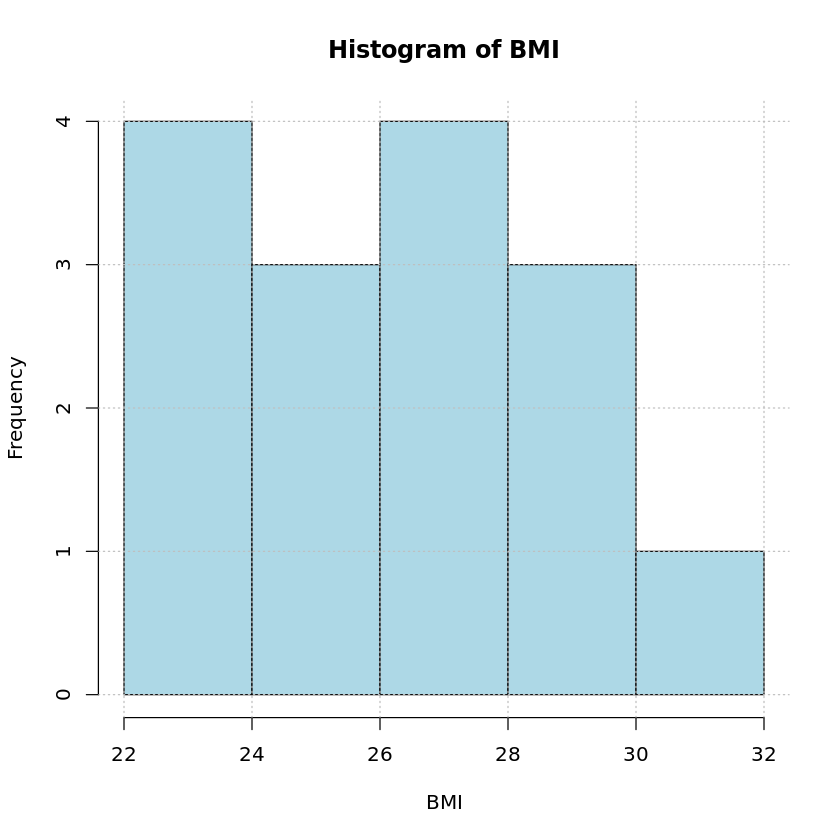

In [16]:
# Step 1: Prepare the Data
data <- data.frame(
  Subject = 1:15,
  BMI = c(22.5, 24.1, 23.0, 27.5, 26.3, 28.1, 29.2, 30.5, 28.9, 27.0, 25.4, 24.9, 23.5, 22.8, 26.7)
)

# Step 2: Create the Histogram
hist(data$BMI, 
     main = "Histogram of BMI", 
     xlab = "BMI", 
     ylab = "Frequency", 
     col = "lightblue", 
     border = "black", 
     breaks = 5)

# Customize the appearance
grid(nx = NULL, ny = NULL, col = "gray", lty = "dotted")


Scatterplots in Public Health Research
Scatterplots are graphical representations used to visualize the relationship between two continuous variables. They are used in public health research to:
•	Identify correlations and trends between variables.
•	Detect outliers and anomalies.
•	Visualize the distribution and spread of data points.
•	Assist in the development of hypotheses for further study.
Example Scenario
Suppose we want to study the relationship between hours of physical activity per week and BMI. We have a dataset of individuals with their respective physical activity levels and BMI.
Example Dataset
Subject	PhysicalActivity (hours/week)	BMI
1	5	22.5
2	3	24.1
3	7	23.0
4	4	27.5
5	6	26.3
6	2	28.1
7	8	29.2
8	4	30.5
9	5	28.9
10	6	27.0
Steps to Create a Scatterplot in R
1.	Prepare the Data: Ensure your data is in a suitable format (e.g., a data frame).
2.	Create the Scatterplot: Use the plot function to create the scatterplot.
3.	Customize and Plot: Customize the scatterplot with titles, labels, and colors.


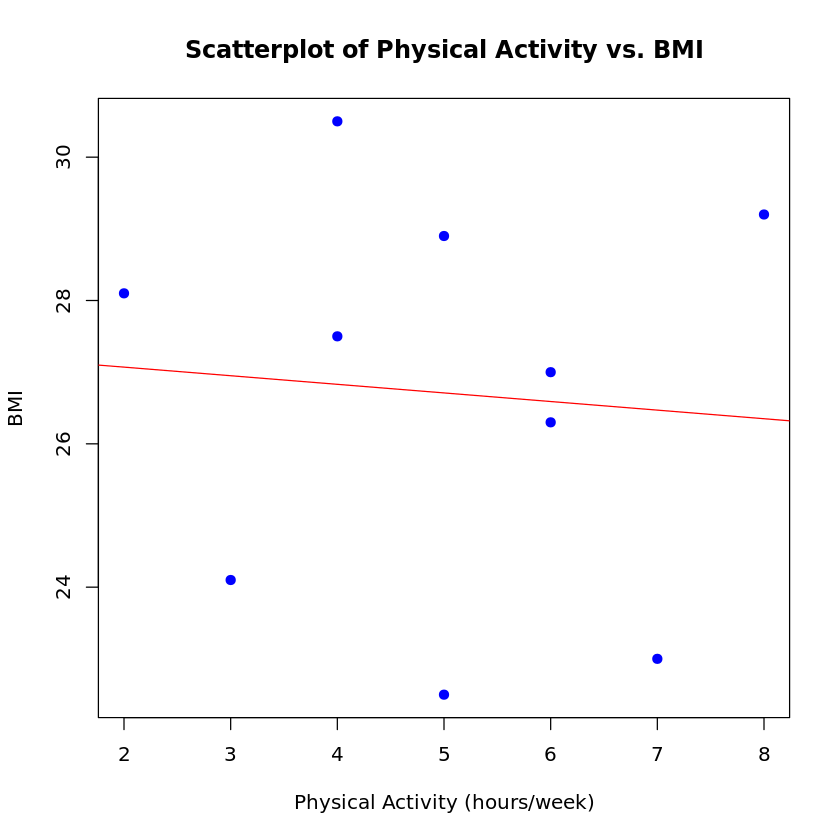

In [17]:
# Step 1: Prepare the Data
data <- data.frame(
  Subject = 1:10,
  PhysicalActivity = c(5, 3, 7, 4, 6, 2, 8, 4, 5, 6),
  BMI = c(22.5, 24.1, 23.0, 27.5, 26.3, 28.1, 29.2, 30.5, 28.9, 27.0)
)

# Step 2: Create the Scatterplot
plot(data$PhysicalActivity, data$BMI, 
     main = "Scatterplot of Physical Activity vs. BMI", 
     xlab = "Physical Activity (hours/week)", 
     ylab = "BMI", 
     pch = 19, 
     col = "blue")

# Add a regression line
abline(lm(BMI ~ PhysicalActivity, data = data), col = "red")


Boxplots are graphical representations that display the distribution of a dataset based on five summary statistics: minimum, first quartile (Q1), median, third quartile (Q3), and maximum. They are used in public health research to:
•	Identify the central tendency and variability of data.
•	Detect outliers and understand the spread of data.
•	Compare distributions across different groups or categories.
Example Scenario
Suppose we want to compare the BMI distributions among three different groups: Control, Low-Fat Diet, and Low-Carb Diet.
Example Dataset
Subject	DietGroup	BMI
1	Control	22.5
2	Control	24.1
3	Control	23.0
4	Control	27.5
5	Control	26.3
6	Low-Fat	28.1
7	Low-Fat	29.2
8	Low-Fat	30.5
9	Low-Fat	28.9
10	Low-Fat	27.0
11	Low-Carb	25.4
12	Low-Carb	24.9
13	Low-Carb	23.5
14	Low-Carb	22.8
15	Low-Carb	26.7
Steps to Create a Boxplot in R
1.	Prepare the Data: Ensure your data is in a suitable format (e.g., a data frame).
2.	Create the Boxplot: Use the boxplot function to create the boxplot.
3.	Customize and Plot: Customize the boxplot with titles, labels, and colors.


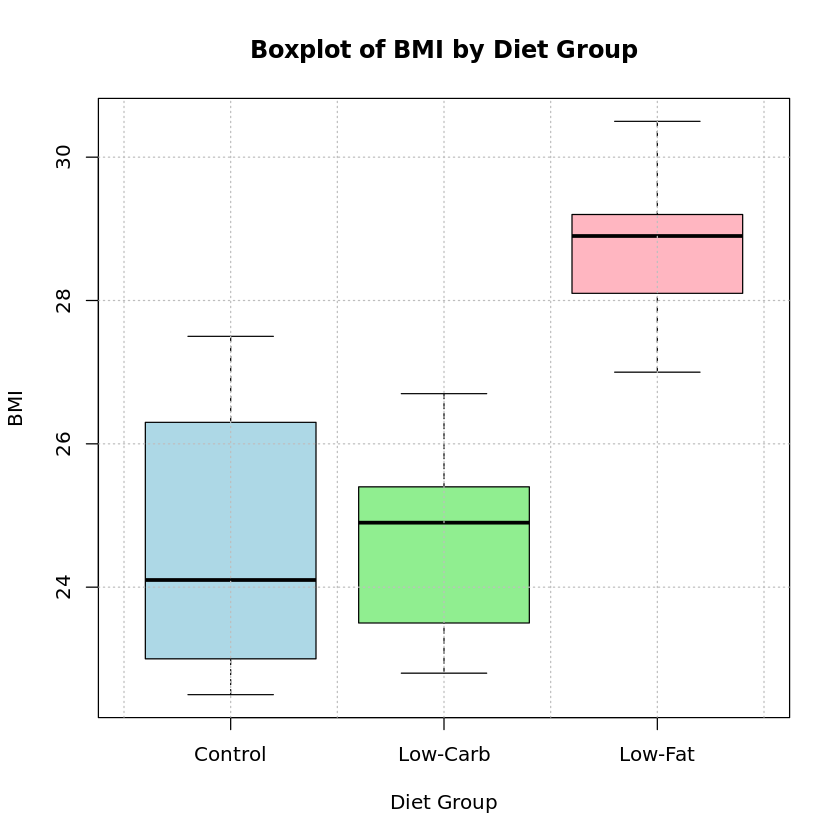

In [18]:
# Step 1: Prepare the Data
data <- data.frame(
  Subject = 1:15,
  DietGroup = factor(c("Control", "Control", "Control", "Control", "Control", 
                       "Low-Fat", "Low-Fat", "Low-Fat", "Low-Fat", "Low-Fat",
                       "Low-Carb", "Low-Carb", "Low-Carb", "Low-Carb", "Low-Carb")),
  BMI = c(22.5, 24.1, 23.0, 27.5, 26.3, 28.1, 29.2, 30.5, 28.9, 27.0, 25.4, 24.9, 23.5, 22.8, 26.7)
)

# Step 2: Create the Boxplot
boxplot(BMI ~ DietGroup, data = data, 
        main = "Boxplot of BMI by Diet Group",
        xlab = "Diet Group", 
        ylab = "BMI", 
        col = c("lightblue", "lightgreen", "lightpink"))

# Step 3: Customize the Appearance
grid(nx = NULL, ny = NULL, col = "gray", lty = "dotted")


Pie Charts in Public Health Research
Pie charts are used in public health research to represent the proportional distribution of categorical data. They help in:
•	Visualizing the relative proportions of different categories.
•	Comparing the distribution of health-related factors such as disease prevalence, resource allocation, and demographic characteristics.
•	Communicating findings in a simple and intuitive manner.
Example Scenario
Suppose we want to visualize the distribution of patients diagnosed with three different types of diseases: Disease A, Disease B, and Disease C in a hospital.
Example Dataset
Disease	Number of Patients
A	40
B	35
C	25
Steps to Create a Pie Chart in R
1.	Prepare the Data: Ensure your data is in a suitable format (e.g., a data frame).
2.	Create the Pie Chart: Use the pie function to create the pie chart.
3.	Customize and Plot: Customize the pie chart with titles and labels.


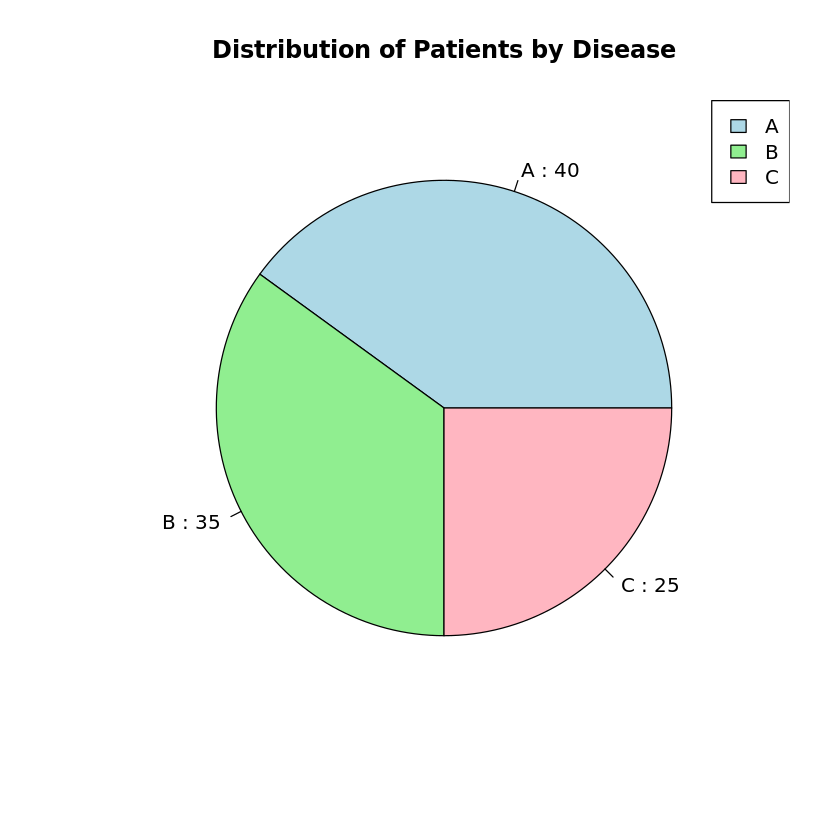

In [20]:
# Step 1: Prepare the Data
data <- data.frame(
  Disease = c("A", "B", "C"),
  NumberOfPatients = c(40, 35, 25)
)

# Step 2: Create the Pie Chart
pie(data$NumberOfPatients, 
    labels = paste(data$Disease, ":", data$NumberOfPatients), 
    main = "Distribution of Patients by Disease",
    col = c("lightblue", "lightgreen", "lightpink"))

# Customize the appearance
legend("topright", legend = data$Disease, fill = c("lightblue", "lightgreen", "lightpink"))


Creating a dataframe in R

In [10]:
cardio_df <- read.csv("../data/cardio10.csv", stringsAsFactors = FALSE)

head(cardio_df)
summary(cardio_df)




,id,age_days,sex,height,weight,sbp,diastolic,cholesterol,gluc,smoking,⋯,dm,egfr,bptreat,statin,uacr,sdi,hba1c,prevent_full_10yr_CVD,prevent_full_10yr_ASCVD,prevent_full_10yr_HF
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,57792,14455,0,164,62,110,70,0,0,0,⋯,0,88,1,1,0.5,2,6.5,0.1994096,0.6573390,0.1994096
2,17274,15452,0,156,48,110,70,0,0,0,⋯,0,80,0,1,1.0,1,5.4,0.2085305,0.7624022,0.2085305
3,59931,15235,1,168,72,110,80,1,0,0,⋯,0,109,0,1,6.7,1,5.6,0.2128746,0.8282949,0.2128746
4,72971,15370,1,178,78,110,70,0,0,0,⋯,0,100,0,1,4.8,1,5.6,0.2157686,0.5408013,0.2157686
5,33519,15184,0,153,63,110,70,0,0,0,⋯,0,81,0,0,2.2,4,5.1,0.2179071,0.3232337,0.2179071
6,52147,15354,1,171,77,120,80,0,0,0,⋯,0,119,0,1,1.5,1,6.4,0.2188558,0.4470985,0.2188558


       id           age_days          sex             height     
 Min.   :    0   Min.   :10964   Min.   :0.0000   Min.   :120.0  
 1st Qu.:24961   1st Qu.:17667   1st Qu.:0.0000   1st Qu.:159.0  
 Median :49934   Median :19701   Median :0.0000   Median :165.0  
 Mean   :49944   Mean   :19469   Mean   :0.3556   Mean   :164.6  
 3rd Qu.:74860   3rd Qu.:21323   3rd Qu.:1.0000   3rd Qu.:170.0  
 Max.   :99999   Max.   :23713   Max.   :1.0000   Max.   :200.0  
     weight            sbp          diastolic         cholesterol   
 Min.   : 30.00   Min.   : 90.0   Min.   :    0.00   Min.   :0.000  
 1st Qu.: 65.00   1st Qu.:120.0   1st Qu.:   80.00   1st Qu.:0.000  
 Median : 72.00   Median :120.0   Median :   80.00   Median :0.000  
 Mean   : 73.43   Mean   :126.8   Mean   :   95.93   Mean   :0.361  
 3rd Qu.: 81.00   3rd Qu.:140.0   3rd Qu.:   90.00   3rd Qu.:0.000  
 Max.   :135.00   Max.   :200.0   Max.   :10000.00   Max.   :2.000  
      gluc           smoking             alco          

dataframe for patients, medications, and bp_levels

In [11]:
# Create data frames from CSV files in ../data
patients_df    <- read.csv("../data/patients.csv", stringsAsFactors = FALSE)
medications_df <- read.csv("../data/medications.csv", stringsAsFactors = FALSE)
bp_df          <- read.csv("../data/bp_readings.csv", stringsAsFactors = FALSE)

head(patients_df)
head(medications_df)
head(bp_df)



,patient_id,first_name,last_name,date_of_birth,sex,race,ethnicity,zip_code
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,1001,John,Doe,4/12/1968,M,White,Non-Hispanic,75201
2,1002,Maria,Lopez,9/30/1975,F,Hispanic,Hispanic,75204
3,1003,James,Smith,1/18/1982,M,Black,Non-Hispanic,75080
4,1004,Linda,Chen,6/5/1990,F,Asian,Non-Hispanic,75024
5,1005,Robert,Johnson,11/22/1959,M,White,Non-Hispanic,75230


,med_id,patient_id,medication_name,dose,frequency,start_date,indication
,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,1001,Lisinopril,10 mg,Once daily,9/1/2024,Hypertension
2,2,1002,Amlodipine,5 mg,Once daily,8/20/2024,Hypertension
3,3,1003,Metoprolol,50 mg,Twice daily,9/10/2024,Hypertension
4,4,1003,Atorvastatin,20 mg,Once daily,9/10/2024,Hyperlipidemia
5,5,1005,Losartan,50 mg,Once daily,9/5/2024,Hypertension


,bp_id,patient_id,reading_date,systolic,diastolic,heart_rate,source
,<int>,<int>,<chr>,<int>,<int>,<int>,<chr>
1,1,1001,9/1/2024,148,92,78,Clinic
2,2,1001,10/1/2024,142,88,76,Home
3,3,1001,11/1/2024,136,84,74,Home
4,4,1002,9/15/2024,132,82,70,Clinic
5,5,1002,10/15/2024,128,80,68,Home
6,6,1003,9/10/2024,150,96,82,Clinic
